In [1]:
import torch
import transformers
import datasets
import sklearn

C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("Bonjour")

Bonjour


In [3]:
print("PyTorch :", torch.__version__)
print("Transformers :", transformers.__version__)
print("Datasets :", datasets.__version__)

PyTorch : 2.13.0+cpu
Transformers : 5.14.1
Datasets : 5.0.1


In [4]:
print("PyTorch fonctionne :", torch.__version__)
print("GPU disponible :", torch.cuda.is_available())

PyTorch fonctionne : 2.13.0+cpu
GPU disponible : False


### Charger le tokenizer BERT

In [7]:
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
print("Tokenizer chargé avec succès !")

Tokenizer chargé avec succès !


### Tokeniser une critique

In [11]:
text = "The movie was great but the ending was disappointing."

In [12]:
inputs = tokenizer(
    text,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

In [13]:
print("input_ids :")
print(inputs["input_ids"])

print("\nattention_mask :")
print(inputs["attention_mask"])

print("\ntoken_type_ids :")
print(inputs["token_type_ids"])

input_ids :
tensor([[  101,  1996,  3185,  2001,  2307,  2021,  1996,  4566,  2001, 15640,
          1012,   102]])

attention_mask :
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])

token_type_ids :
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


### Affichage des tokens

In [14]:
tokens = tokenizer.tokenize(text)
print(tokens)

['the', 'movie', 'was', 'great', 'but', 'the', 'ending', 'was', 'disappointing', '.']


In [15]:
print(tokenizer.convert_tokens_to_ids(tokens))

[1996, 3185, 2001, 2307, 2021, 1996, 4566, 2001, 15640, 1012]


In [16]:
print(tokenizer.convert_ids_to_tokens(inputs["input_ids"][0]))

['[CLS]', 'the', 'movie', 'was', 'great', 'but', 'the', 'ending', 'was', 'disappointing', '.', '[SEP]']


### Rôle des trois tenseurs

- **input_ids** : contient les identifiants numériques des tokens dans le vocabulaire BERT.
- **attention_mask** : indique quels tokens doivent être pris en compte par le mécanisme d'attention. La valeur 1 correspond à un token réel et 0 à un token de padding.
- **token_type_ids** : indique à quelle phrase appartient chaque token lorsqu'une entrée contient deux phrases. Les valeurs 0 et 1 représentent respectivement la première et la deuxième phrase.

### Chargement du modèle BERT

In [18]:
from transformers import BertForSequenceClassification
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)
print("Modèle BERT chargé !")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4259.39it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

Modèle BERT chargé !


### Chargement du dataset IMDB

In [3]:
from datasets import load_dataset
dataset = load_dataset("stanfordnlp/imdb")

C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 282023.86 examples/s]


In [4]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [5]:
train_dataset = dataset["train"].shuffle(seed=42).select(range(2500))
test_dataset = dataset["test"].shuffle(seed=42).select(range(2500))

print("Train :", len(train_dataset))
print("Test :", len(test_dataset))

Train : 2500
Test : 2500


### Tokeniser les 2500 critiques

In [9]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [10]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [11]:
train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

Map: 100%|██████████| 2500/2500 [00:01<00:00, 1789.02 examples/s]


### Préparation de PyTorch

In [12]:
train_tokenized = train_tokenized.remove_columns(["text"])
test_tokenized = test_tokenized.remove_columns(["text"])

In [13]:
train_tokenized = train_tokenized.rename_column("label", "labels")
test_tokenized = test_tokenized.rename_column("label", "labels")

In [14]:
train_tokenized.set_format("torch")
test_tokenized.set_format("torch")

In [15]:
print(train_tokenized[0])

{'labels': tensor(1), 'input_ids': tensor([  101,  2045,  2003,  2053,  7189,  2012,  2035,  2090,  3481,  3771,
         1998,  6337,  2099,  2021,  1996,  2755,  2008,  2119,  2024,  2610,
         2186,  2055,  6355,  6997,  1012,  6337,  2099,  3504, 15594,  2100,
         1010,  3481,  3771,  3504,  4438,  1012,  6337,  2099, 14811,  2024,
         3243,  3722,  1012,  3481,  3771,  1005,  1055,  5436,  2024,  2521,
         2062,  8552,  1012,  1012,  1012,  3481,  3771,  3504,  2062,  2066,
         3539,  8343,  1010,  2065,  2057,  2031,  2000,  3962, 12319,  1012,
         1012,  1012,  1996,  2364,  2839,  2003,  5410,  1998,  6881,  2080,
         1010,  2021,  2031,  1000, 17936,  6767,  7054,  3401,  1000,  1012,
         2111,  2066,  2000, 12826,  1010,  2000,  3648,  1010,  2000, 16157,
         1012,  2129,  2055,  2074,  9107,  1029,  6057,  2518,  2205,  1010,
         2111,  3015,  3481,  3771,  3504,  2137,  2021,  1010,  2006,  1996,
         2060,  2192,  1010, 

### Création des DataLoaders

In [24]:
from torch.utils.data import DataLoader

batch_size = 8

train_loader = DataLoader(
    train_tokenized,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_tokenized,
    batch_size=batch_size,
    shuffle=False
)

print("Batchs train :", len(train_loader))
print("Batchs test :", len(test_loader))

Batchs train : 313
Batchs test : 313


In [19]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)
model.to(device)

Device : cpu


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

### Optimiseur AdamW

In [20]:
from torch.optim import AdamW
optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

### Entraînement

In [26]:
from sklearn.metrics import accuracy_score
import time

epochs = 3

train_losses = []
train_accuracies = []

for epoch in range(epochs):

    model.train()

    total_loss = 0
    predictions = []
    true_labels = []

    total_batches = len(train_loader)

    print(f"Début Epoch {epoch+1}/{epochs} - {total_batches} batches", flush=True)

    start_time = time.time()

    for batch_idx, batch in enumerate(train_loader):

        print(
            f"Traitement du batch {batch_idx+1}/{total_batches}...",
            flush=True
        )

        batch = {
            k: v.to(device)
            for k, v in batch.items()
        }

        optimizer.zero_grad()

        outputs = model(**batch)

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(batch["labels"].cpu().numpy())

        print(
            f"Batch {batch_idx+1}/{total_batches} terminé - "
            f"Loss: {loss.item():.4f}",
            flush=True
        )

    avg_loss = total_loss / len(train_loader)
    accuracy = accuracy_score(true_labels, predictions)

    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)

    elapsed = time.time() - start_time

    print(
        f"\nEpoch {epoch+1}/{epochs} terminée "
        f"- Loss: {avg_loss:.4f} "
        f"- Accuracy: {accuracy:.4f} "
        f"- Temps: {elapsed/60:.1f} min",
        flush=True
    )

Début Epoch 1/3 - 313 batches
Traitement du batch 1/313...
Batch 1/313 terminé - Loss: 0.3360
Traitement du batch 2/313...
Batch 2/313 terminé - Loss: 0.7522
Traitement du batch 3/313...
Batch 3/313 terminé - Loss: 0.3801
Traitement du batch 4/313...
Batch 4/313 terminé - Loss: 0.3818
Traitement du batch 5/313...
Batch 5/313 terminé - Loss: 0.2808
Traitement du batch 6/313...
Batch 6/313 terminé - Loss: 0.1801
Traitement du batch 7/313...
Batch 7/313 terminé - Loss: 0.7582
Traitement du batch 8/313...
Batch 8/313 terminé - Loss: 0.3556
Traitement du batch 9/313...
Batch 9/313 terminé - Loss: 0.7364
Traitement du batch 10/313...
Batch 10/313 terminé - Loss: 0.5107
Traitement du batch 11/313...
Batch 11/313 terminé - Loss: 0.1882
Traitement du batch 12/313...
Batch 12/313 terminé - Loss: 0.6630
Traitement du batch 13/313...
Batch 13/313 terminé - Loss: 0.2868
Traitement du batch 14/313...
Batch 14/313 terminé - Loss: 0.2656
Traitement du batch 15/313...
Batch 15/313 terminé - Loss: 0.702

KeyboardInterrupt: 

### Evaluation

##### Accuracy

In [32]:
from sklearn.metrics import accuracy_score
from tqdm import tqdm

model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for batch in tqdm(test_loader, desc="Évaluation"):

        batch = {
            k: v.to(device)
            for k, v in batch.items()
        }

        outputs = model(**batch)

        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(batch["labels"].cpu().numpy())

accuracy = accuracy_score(true_labels, predictions)

print(f"Accuracy sur le test : {accuracy:.4f}")


Évaluation: 100%|██████████| 313/313 [09:59<00:00,  1.92s/it]

Accuracy sur le test : 0.8516


##### Matrice de confusion

In [33]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(true_labels, predictions)
print("Matrice de confusion :")
print(cm)

Matrice de confusion :
[[1016  227]
 [ 144 1113]]


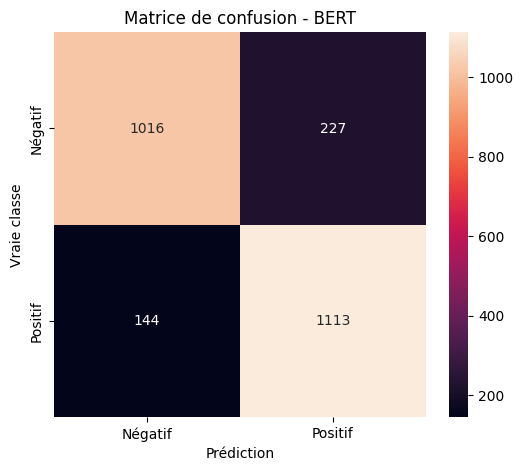

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Négatif", "Positif"],
    yticklabels=["Négatif", "Positif"]
)

plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.title("Matrice de confusion - BERT")
plt.show()

##### Precision, Recall et F1

In [35]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predictions,
        target_names=["Négatif", "Positif"]
    )
)

              precision    recall  f1-score   support

     Négatif       0.88      0.82      0.85      1243
     Positif       0.83      0.89      0.86      1257

    accuracy                           0.85      2500
   macro avg       0.85      0.85      0.85      2500
weighted avg       0.85      0.85      0.85      2500



### Partie C

In [39]:
text = "The movie was great but the ending was disappointing"

attention_inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=128
)

attention_inputs = {
    k: v.to(device)
    for k, v in attention_inputs.items()
}

print(tokenizer.convert_ids_to_tokens(
    attention_inputs["input_ids"][0]
))

['[CLS]', 'the', 'movie', 'was', 'great', 'but', 'the', 'ending', 'was', 'disappointing', '[SEP]']


In [41]:
model.config._attn_implementation = "eager"

print("Modèle actuel configuré en mode eager")

model.eval()

with torch.no_grad():

    outputs = model(
        **attention_inputs,
        output_attentions=True
    )

attentions = outputs.attentions

print("Nombre de couches :", len(attentions))

Modèle actuel configuré en mode eager
Nombre de couches : 12


In [42]:
last_layer = attentions[-1]

print(last_layer.shape)

torch.Size([1, 12, 11, 11])


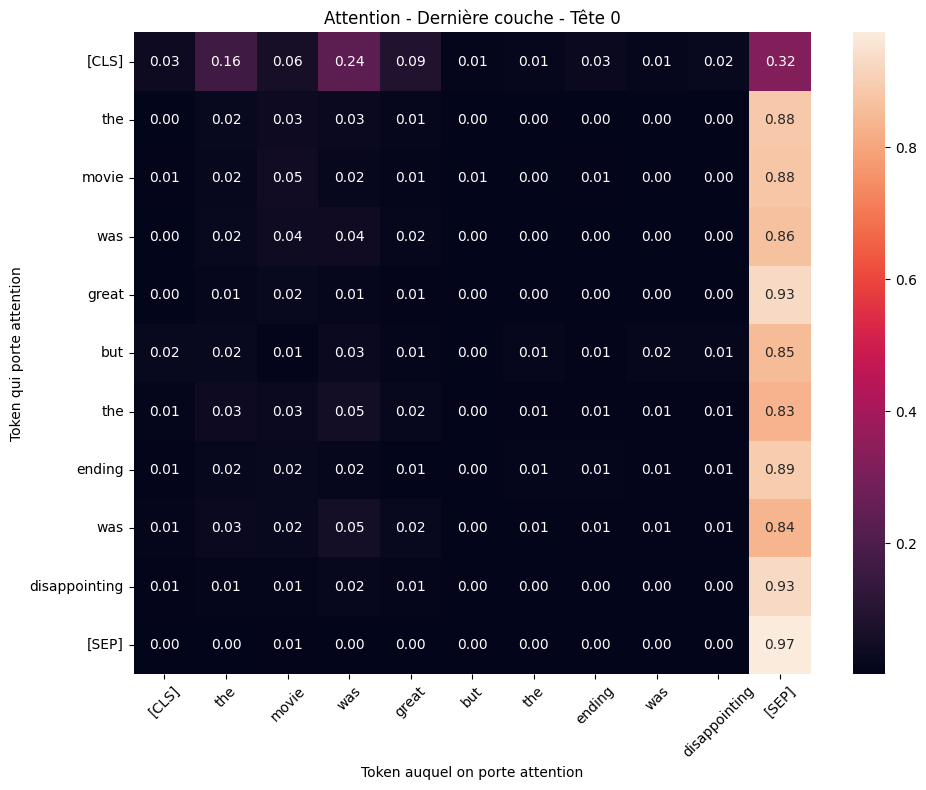

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

tokens = tokenizer.convert_ids_to_tokens(
    attention_inputs["input_ids"][0]
)

head_0 = last_layer[0, 0].cpu().numpy()

plt.figure(figsize=(10, 8))

sns.heatmap(
    head_0,
    annot=True,
    fmt=".2f",
    xticklabels=tokens,
    yticklabels=tokens
)

plt.xlabel("Token auquel on porte attention")
plt.ylabel("Token qui porte attention")
plt.title("Attention - Dernière couche - Tête 0")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [44]:
ending_index = tokens.index("ending")

attention_ending = head_0[ending_index]

for token, score in zip(tokens, attention_ending):
    print(f"{token:15s} : {score:.4f}")

[CLS]           : 0.0086
the             : 0.0182
movie           : 0.0224
was             : 0.0163
great           : 0.0051
but             : 0.0038
the             : 0.0093
ending          : 0.0107
was             : 0.0075
disappointing   : 0.0073
[SEP]           : 0.8908


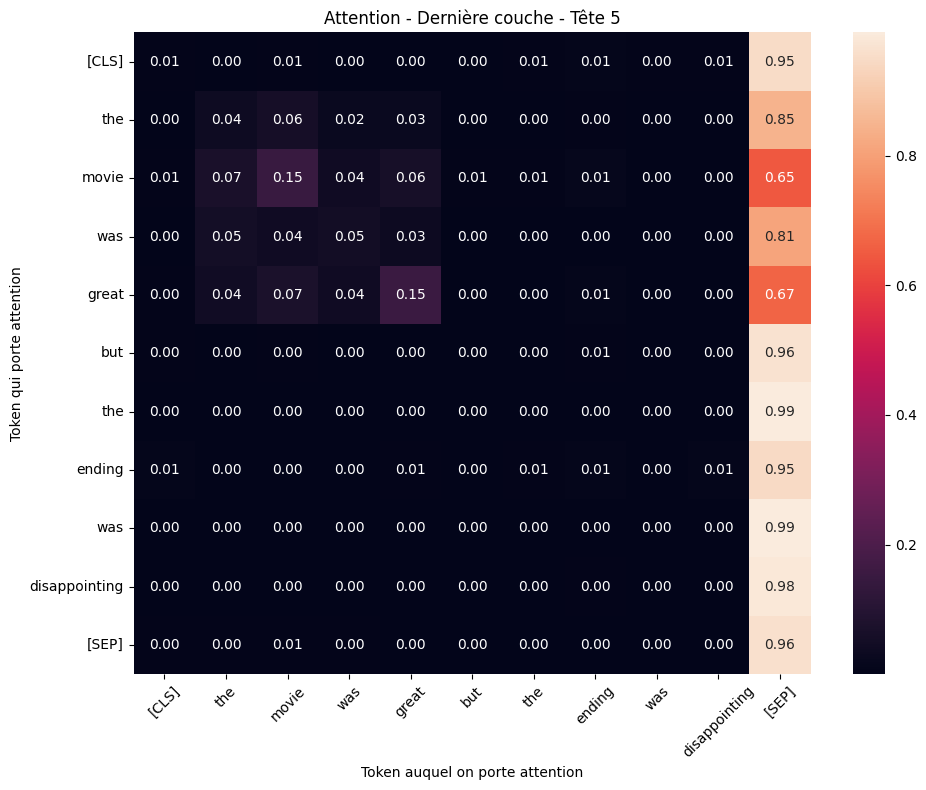

In [45]:
head_5 = last_layer[0, 5].cpu().numpy()

plt.figure(figsize=(10, 8))

sns.heatmap(
    head_5,
    annot=True,
    fmt=".2f",
    xticklabels=tokens,
    yticklabels=tokens
)

plt.xlabel("Token auquel on porte attention")
plt.ylabel("Token qui porte attention")
plt.title("Attention - Dernière couche - Tête 5")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#### Partie D : Tableau comparatif BERT / GPT / T5

## Comparaison des architectures Transformer

| Famille | Exemple | Architecture | Mécanisme d'attention | Entraînement | Applications |
|---|---|---|---|---|---|
| Encoder-only | BERT | Encodeur uniquement | Attention bidirectionnelle | Masked Language Modeling (MLM) | Classification, NER, analyse de sentiment |
| Decoder-only | GPT | Décodeur uniquement | Attention causale/masquée | Prédiction auto-régressive du token suivant | Génération de texte, dialogue, complétion |
| Encoder-Decoder | T5 | Encodeur + Décodeur | Attention bidirectionnelle dans l'encodeur + attention croisée dans le décodeur | Text-to-Text | Traduction, résumé, génération de texte |

### Pourquoi le positional encoding est-il nécessaire ?

Le Transformer traite les tokens d'une séquence en parallèle grâce au mécanisme d'attention. Contrairement aux LSTM, il ne possède pas de mécanisme récurrent permettant de connaître naturellement l'ordre des tokens.

Par exemple, les phrases « Le chien mange la nourriture » et « La nourriture mange le chien » contiennent les mêmes mots mais dans un ordre différent. Sans information de position, le Transformer aurait des difficultés à distinguer ces deux séquences.

Le positional encoding ajoute donc une information indiquant la position de chaque token dans la séquence. Il permet au modèle de prendre en compte l'ordre des mots.

Les LSTM n'ont pas besoin d'un positional encoding explicite car ils traitent les tokens séquentiellement : à chaque étape, l'état caché contient implicitement l'information provenant des tokens précédents.

### Rôle du facteur √dk dans le scaled dot-product attention

Dans le mécanisme d'attention, les scores sont calculés à partir du produit scalaire entre les vecteurs Query (Q) et Key (K) :

Attention(Q,K,V) = softmax(QKᵀ / √dk)V

Le facteur √dk sert à réduire l'amplitude des valeurs obtenues par le produit scalaire lorsque la dimension des vecteurs dk est grande.

Sans cette mise à l'échelle, les scores d'attention pourraient devenir très importants. La fonction softmax produirait alors des probabilités très proches de 0 ou de 1, ce qui provoquerait des gradients très faibles et rendrait l'apprentissage plus difficile.

La division par √dk permet donc de stabiliser les valeurs des scores d'attention et de faciliter l'apprentissage du modèle.